In [1]:
import pandas as pd
from main import SatCLIPLightningModule
import location_encoder as LE
from temporal_encoding import Fourier, Direct
from tqdm import tqdm
from matplotlib import pyplot as plt
import torch
import torch.nn as nn
import numpy as np

from mpl_toolkits.basemap import Basemap
from mpl_toolkits.axes_grid1 import make_axes_locatable

from utils import *
import torch.nn.functional as F

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


# Create the spatiotemporal train-test splits

In [3]:
# Load the GHCN dataset
ghcn_df = pd.read_csv('../data/ghcn_data/ghcn_2021_2026_temperature.csv')
print(len(ghcn_df))
ghcn_df.head()

104066815


,ID,Date,Element,Value,MFlag,QFlag,SFlag,OBS-TIME,Latitude,Longitude,Elevation,Name
0,AE000041196,20210101,TMAX,278,NaN,NaN,S,NaN,25.333,55.517,34.0,SHARJAH INTER. AIRP
1,AE000041196,20210101,PRCP,0,D,NaN,S,NaN,25.333,55.517,34.0,SHARJAH INTER. AIRP
2,AEM00041194,20210101,TMAX,266,NaN,NaN,S,NaN,25.255,55.364,10.4,DUBAI INTL
3,AEM00041194,20210101,TMIN,178,NaN,NaN,S,NaN,25.255,55.364,10.4,DUBAI INTL
4,AEM00041194,20210101,PRCP,0,NaN,NaN,S,NaN,25.255,55.364,10.4,DUBAI INTL


In [4]:
# Filter GHCN to quality controlled data and limit to TMAX (maximum temperature) observations
ghcn_qc_temp_df = ghcn_df[(ghcn_df["Element"]=="TMAX") & (ghcn_df["QFlag"].isna())].copy()
ghcn_qc_temp_df['Date'] = pd.to_datetime(ghcn_qc_temp_df['Date'], format="%Y%m%d")
ghcn_qc_temp_df.loc[:, 'DayOfYear'] = (ghcn_qc_temp_df['Date'].dt.dayofyear - 1) / 364.0
ghcn_qc_temp_df.head()

,ID,Date,Element,Value,MFlag,QFlag,SFlag,OBS-TIME,Latitude,Longitude,Elevation,Name,DayOfYear
0,AE000041196,2021-01-01,TMAX,278,NaN,NaN,S,NaN,25.3330,55.5170,34.0,SHARJAH INTER. AIRP,0.0
2,AEM00041194,2021-01-01,TMAX,266,NaN,NaN,S,NaN,25.2550,55.3640,10.4,DUBAI INTL,0.0
5,AEM00041217,2021-01-01,TMAX,262,NaN,NaN,S,NaN,24.4330,54.6510,26.8,ABU DHABI INTL,0.0
7,AEM00041218,2021-01-01,TMAX,250,NaN,NaN,S,NaN,24.2620,55.6090,264.9,AL AIN INTL,0.0
67,ASN00031108,2021-01-01,TMAX,290,NaN,NaN,a,NaN,-17.1347,145.4281,594.0,WALKAMIN RESEARCH STATION,0.0


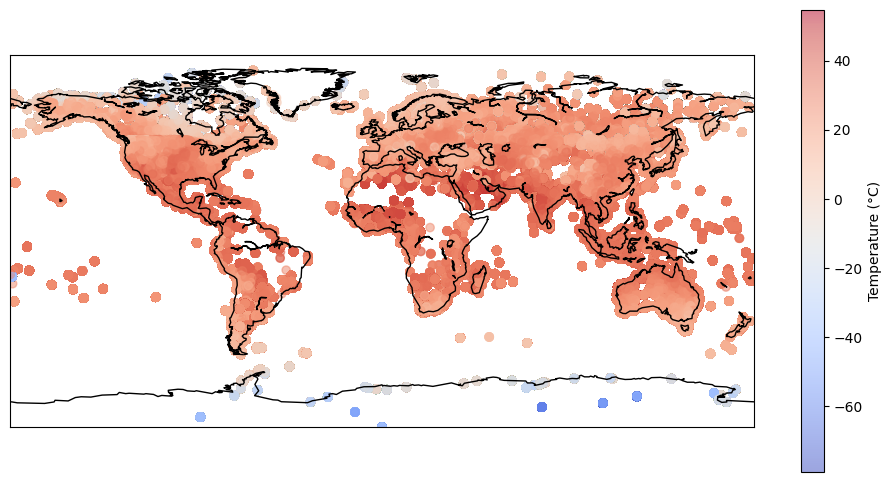

In [5]:
# Plot the temperatures on a map
fig, ax = plt.subplots(figsize=(12, 6))
m = Basemap(projection='cyl', resolution='c', ax=ax)
m.drawcoastlines()
sc = ax.scatter(ghcn_qc_temp_df['Longitude'].values, ghcn_qc_temp_df['Latitude'].values, c=ghcn_qc_temp_df['Value'].values/10, cmap='coolwarm', marker='o', alpha=0.5)
fig.colorbar(sc, label='Temperature (°C)', ax=ax)

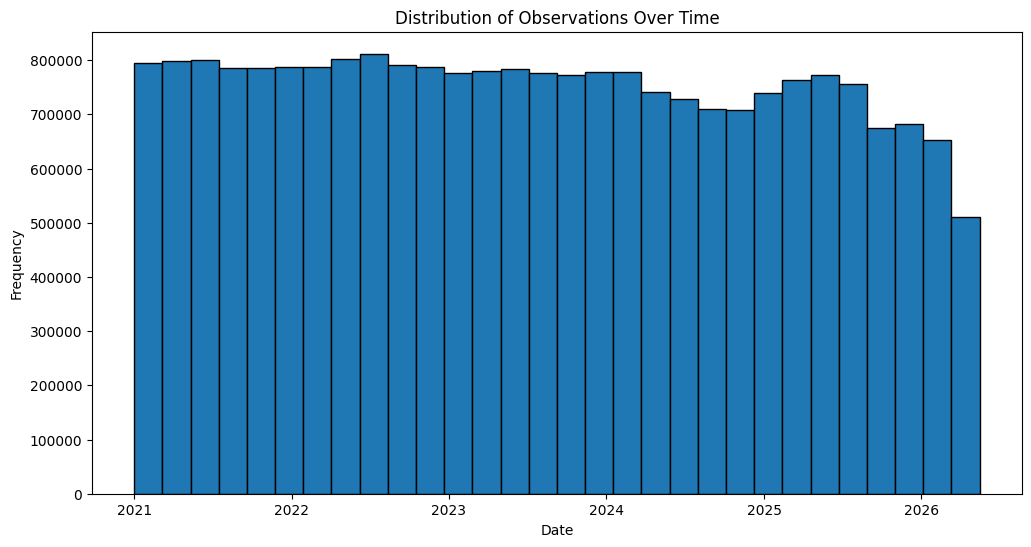

In [6]:
# Plot histogram of observations over time for all stations
plt.figure(figsize=(12, 6))
plt.hist(ghcn_qc_temp_df['Date'], bins=30, edgecolor='black')
plt.xlabel('Date')
plt.ylabel('Frequency')
plt.title('Distribution of Observations Over Time')
plt.show()

Text(0.5, 1.0, 'Temperature Over Time for Station USC00309292')

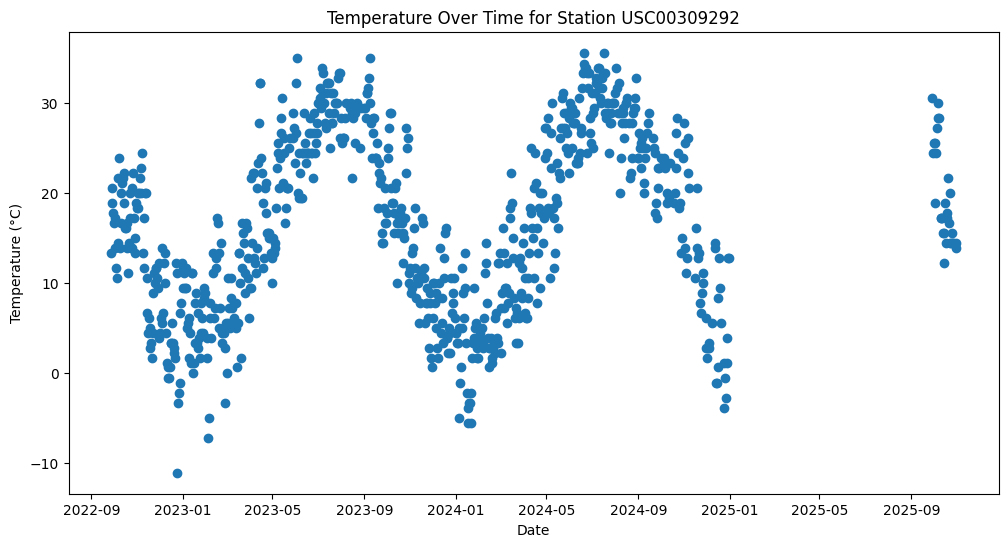

In [7]:
# Plot the distribution of temperatures over time for a randomly selected station
import random
random_station = random.choice(ghcn_qc_temp_df['ID'].unique())
station_df = ghcn_qc_temp_df[ghcn_qc_temp_df['ID']== random_station]
plt.figure(figsize=(12, 6))
plt.scatter(station_df['Date'], station_df['Value']/10, marker='o', linestyle='-', label=f'Station: {random_station}')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title(f'Temperature Over Time for Station {random_station}')

# Create Subsampled Datasets for Quick Testing

In [8]:
# Extract the relevant columns for spatial evaluation (ALWAYS RUN THIS BEFORE SUBSAMPLING)
temp_data = torch.tensor(ghcn_qc_temp_df[['Longitude', 'Latitude', 'DayOfYear', 'Value']].values, dtype=torch.float32)
dates = ghcn_qc_temp_df['Date']
ids = ghcn_qc_temp_df['ID']
all_station_ids = ids.unique()

print("Number of observations:", temp_data.shape[0])
print("Number of unique stations:", len(all_station_ids))

Number of observations: 22614137
Number of unique stations: 14742


In [9]:
# Subsample by samples
NUM_SAMPLES = 200_000
sampled_indices = np.random.choice(temp_data.shape[0], size=NUM_SAMPLES, replace=False)
temp_data = temp_data[sampled_indices, :]
dates = dates.iloc[sampled_indices]
ids = ids.iloc[sampled_indices]
print("Number of sampled observations:", temp_data.shape[0])

Number of sampled observations: 200000


In [20]:
# Subsample by stations
NUM_STATIONS = 2000
sampled_station_ids = np.random.choice(all_station_ids, size=NUM_STATIONS, replace=False)
temp_data = temp_data[ids.isin(sampled_station_ids).to_numpy(), :]
dates = dates[ids.isin(sampled_station_ids).to_numpy()]
ids = ids[ids.isin(sampled_station_ids).to_numpy()]
print("Number of sampled stations:", len(sampled_station_ids))
print("Number of sampled observations:", temp_data.shape[0])

Number of sampled stations: 2000
Number of sampled observations: 3056681


In [10]:
# Create the spatial checkerboard splits for the GHCN dataset
delta_degree = 16
splits = checkerboard_splits(temp_data[:, :2], torch.tensor([delta_degree, delta_degree])).flatten()

In [13]:
# Create temporal splits for the GHCN dataset
delta_day = 30
# convert dates into days since the first date
days_since_first = torch.tensor((dates - dates.min()).dt.days.to_numpy())
splits = temporal_splits(days_since_first, delta_day)

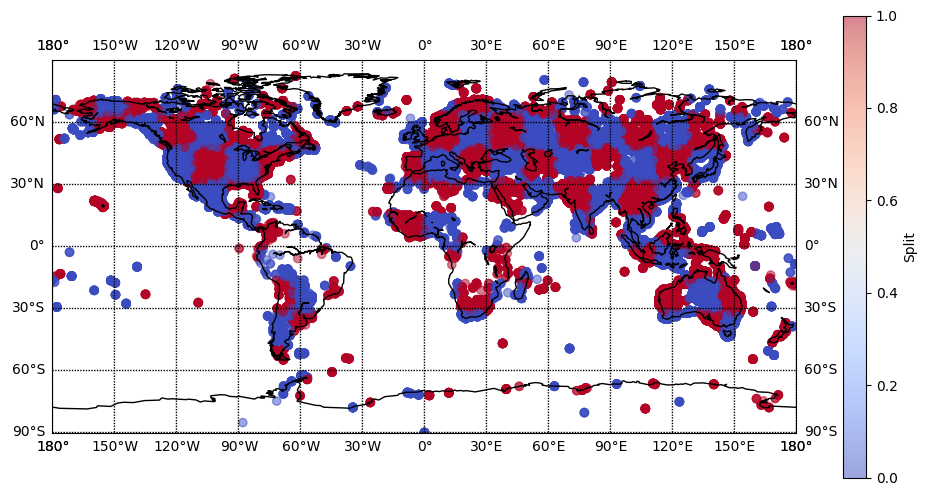

In [11]:
# Plot the splits on a map
fig, ax = plt.subplots(figsize=(12, 6))
m = Basemap(projection='cyl', resolution='c', ax=ax)
m.drawcoastlines()
# Parallels (Latitudes) range from -90 to 90
m.drawparallels(np.arange(-90, 90, 30), labels=[True, True, False, False])

# Meridians (Longitudes) range from 0 to 360 (or -180 to 180 depending on projection)
m.drawmeridians(np.arange(0, 360, 30), labels=[False, False, True, True])

sc = ax.scatter(temp_data[:, 0], temp_data[:, 1], c=splits, cmap='coolwarm', marker='o', alpha=0.5)
fig.colorbar(sc, label='Split', ax=ax)

In [ ]:
# Plot GIF of the dataset over time
# Make a gif over time of the dataset
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from mpl_toolkits.axes_grid1 import make_axes_locatable
from PIL import Image
import io
from tqdm import tqdm

frames = []

days_win = 30

for date in tqdm(dates.unique()):
    # Find images within a window of days
    temp_window = temp_data[(dates == date).to_numpy(), :]
    dates_window = dates[(dates == date)]

    # cs = np.array([np.array(x)/255.0 for x in df_window['avg_color'].values])
    # cs = np.minimum(cs, 1.0)

    # Plot the average colors of the images in this window on the map
    fig, ax = plt.subplots(1,1, figsize=(10, 5))

    m = Basemap(projection='cyl', resolution='c', ax=ax)
    m.drawcoastlines()

    sc = ax.scatter(temp_window[:,0], temp_window[:,1], c=temp_window[:,3]/10, cmap='coolwarm', marker='o', alpha=0.5)
    ax.set_title(f"Date: {date.strftime('%Y-%m-%d')}")
    ax.legend()

    buf = io.BytesIO()
    fig.savefig(buf, format='png')
    buf.seek(0)
    frames.append(Image.open(buf))

    if len(frames) > 30:
        break

# Save as GIF
frames[0].save('results/ghcn_temporal_evolution.gif', format='GIF', append_images=frames[1:], save_all=True, duration=500, loop=0)

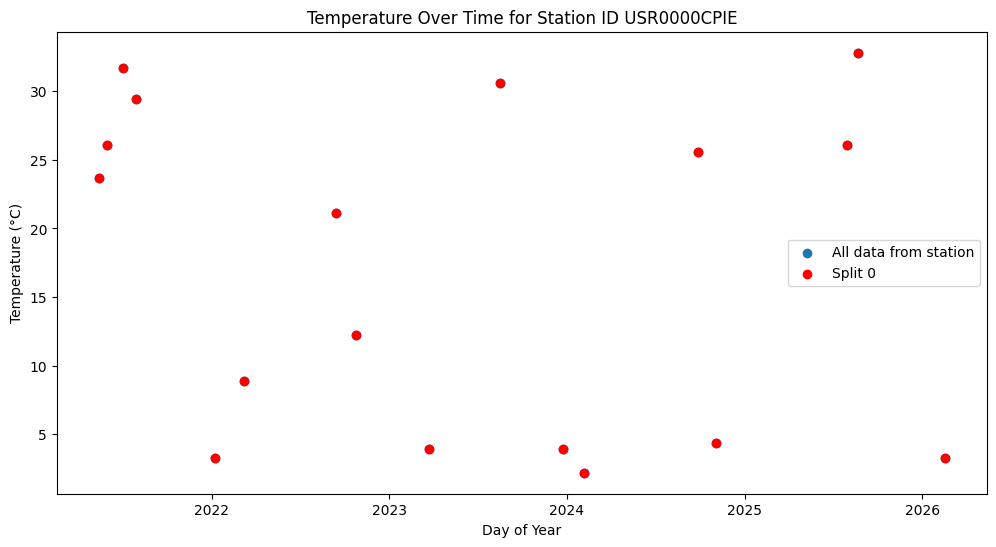

In [12]:
# Plot data for a single station over time from the subset
rand_row = random.choice(range(len(temp_data)))
rand_station_id = ids.iloc[rand_row]
station_data = temp_data[(ids == rand_station_id).to_numpy(), :]
station_dates = dates[(ids == rand_station_id).to_numpy()]
station_splits = splits[(ids == rand_station_id).to_numpy()]

# Plot the temperature over time for this station
split_id = 0
plt.figure(figsize=(12, 6))
plt.scatter(station_dates, station_data[:, 3]/10, marker='o', linestyle='-', label=f'All data from station')
plt.scatter(station_dates[station_splits.numpy() == split_id], station_data[station_splits.numpy() == split_id, 3]/10, marker='o', color="red", linestyle='-', label=f'Split {split_id}')

plt.xlabel('Day of Year')
plt.ylabel('Temperature (°C)')
plt.title(f'Temperature Over Time for Station ID {rand_station_id}')
plt.legend()

# Perform fine-tuning for a location encoder

In [45]:
# Free up GPU memory by emptying the cache
torch.cuda.empty_cache()


In [46]:
# Setup initial datasets
train_split = 0

train = temp_data[splits == train_split, :]
test = temp_data[splits != train_split, :]

# Get a sample of the train and test splits
train_sample = train
test_sample = test
# train_sample = train[np.random.choice(train.shape[0], size=100000, replace=False)]
# test_sample = test[np.random.choice(test.shape[0], size=100000, replace=False)]

# Sample the embeddings for the train split
train_coords = train_sample[:, :3].detach().clone().double().to(device)
test_coords = test_sample[:, :3].detach().clone().double().to(device)

In [55]:
EVAL_TYPE = "mlp" # Can be linear or mlp
print(f"Train coords shape: {train_coords.shape}")
print(f"Test coords shape: {test_coords.shape}")

Train coords shape: torch.Size([102775, 3])
Test coords shape: torch.Size([97225, 3])


In [77]:
# Load a pre-trained spatio-temporal SatCLIP encoder
# ckpt_path = '/home/leca5365/Documents/satclip/satclip/satclip_temporal_logs/satclip-s2-temporal-55k-temporalsplits-fixednormalizeddayofyear/satclip-fixed-normalized-day-of-year/checkpoints/last.ckpt'
# ckpt_path = '/home/leca5365/Documents/satclip/satclip/satclip_temporal_logs/satclip-s2-satcliploss-100k/satclip-s2-satcliploss-100k/checkpoints/last-v2.ckpt'
# ckpt_path = '/home/leca5365/Documents/satclip/satclip/satclip_temporal_logs/satclip-s2-softloss-100k/satclip-s2-softloss-100k/checkpoints/last.ckpt'
ckpt_path = '/home/leca5365/Documents/satclip/satclip/satclip_temporal_logs/satclip-s2-satcliploss-1M/satclip-s2-satcliploss-1M/checkpoints/last-v1.ckpt'

lightning_model = SatCLIPLightningModule.load_from_checkpoint(ckpt_path)

lightning_model.eval()
spatiotemporal_enc = lightning_model.model.location
visual_enc = lightning_model.model.visual

# Get the embeddings for the GHCN dataset using the pre-trained spatio-temporal SatCLIP encoder
spatiotemporal_enc = spatiotemporal_enc.to(device)
with torch.no_grad():
    train_embeddings = spatiotemporal_enc(train_coords).detach()
    test_embeddings = spatiotemporal_enc(test_coords).detach()

using pretrained moco vit16
using loss function: satclip_loss
using temporal model: True


In [52]:
class MLP(nn.Module):
    def __init__(self, input_dim, dim_hidden, num_layers, out_dims):
        super(MLP, self).__init__()

        layers = []
        layers += [nn.Linear(input_dim, dim_hidden, bias=True), nn.ReLU()] # Input layer
        layers += [nn.Linear(dim_hidden, dim_hidden, bias=True), nn.ReLU()] * num_layers # Hidden layers
        layers += [nn.Linear(dim_hidden, out_dims, bias=True)] # Output layer

        self.features = nn.Sequential(*layers)

    def forward(self, x):
        return self.features(x)

In [78]:
# Create a DataLoader for the train embeddings and values
train_dataset = torch.utils.data.TensorDataset(train_embeddings, train_sample[:, 3].detach().clone().double().to(device).unsqueeze(1))
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=8096, shuffle=True)

# Test dataloader
test_dataset = torch.utils.data.TensorDataset(test_embeddings, test_sample[:, 3].detach().clone().double().to(device).unsqueeze(1))
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=8096, shuffle=False)

if EVAL_TYPE == "mlp": 
  pred_model = MLP(input_dim=256, dim_hidden=64, num_layers=2, out_dims=1).double().to(device)
elif EVAL_TYPE == "linear":
  pred_model = nn.Linear(train_embeddings.shape[1], 1, dtype=torch.float64).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(pred_model.parameters(), lr=1e-3)

epoch_losses = []
epochs = 200
running_loss = torch.zeros(1, device=device)

for epoch in range(epochs):
  pred_model.train()
  running_loss.zero_()  # Reset running loss for the epoch

  for batch in train_loader:
    optimizer.zero_grad()
    embeddings, values = batch
    # Forward pass
    y_pred = pred_model(embeddings.to(device))
    # Compute the loss
    loss = criterion(y_pred, values.to(device))
    # Backward pass
    loss.backward()
    # Update the parameters
    optimizer.step()
    # Append the loss to the list
    # losses.append(loss.item())

    running_loss += loss.detach() * embeddings.size(0)  # Multiply by batch size to get total loss for the batch

  epoch_loss = (running_loss / len(train_loader.dataset)).item()
  epoch_losses.append(epoch_loss)

  if (epoch) % 10 == 0:
    print(f"Epoch {epoch + 1}, Loss: {epoch_loss:.4f}")

Epoch 1, Loss: 45568.5625
Epoch 11, Loss: 5177.7280
Epoch 21, Loss: 4222.6689
Epoch 31, Loss: 3907.7183
Epoch 41, Loss: 3850.0696
Epoch 51, Loss: 3826.2341
Epoch 61, Loss: 3812.8755
Epoch 71, Loss: 3802.2520
Epoch 81, Loss: 3791.3413
Epoch 91, Loss: 3780.8191
Epoch 101, Loss: 3774.9170
Epoch 111, Loss: 3764.3752
Epoch 121, Loss: 3759.7744
Epoch 131, Loss: 3751.6235
Epoch 141, Loss: 3750.9536
Epoch 151, Loss: 3743.5815
Epoch 161, Loss: 3731.8818
Epoch 171, Loss: 3730.4648
Epoch 181, Loss: 3723.6155
Epoch 191, Loss: 3723.0105


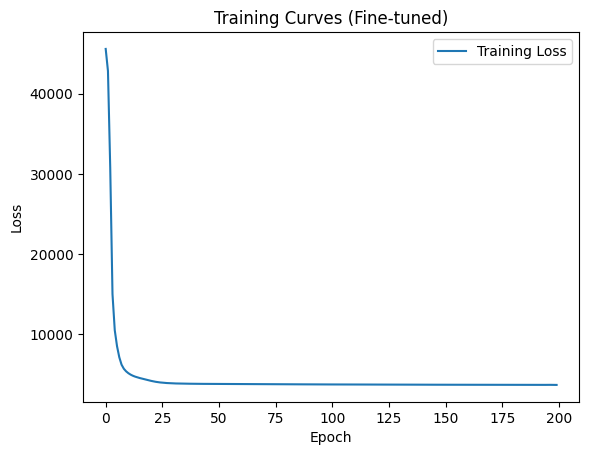

In [79]:
# Plot training curves for the fine-tuned model
plt.plot(list(range(len(epoch_losses))), epoch_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Curves (Fine-tuned)')
plt.legend()
plt.show()

In [80]:
# Run test
preds = []
actuals = []

with torch.no_grad():
  pred_model.eval()

  for batch in test_loader:
    embeddings, values = batch
    y_pred_test = pred_model(embeddings.double().to(device))
    preds.extend(y_pred_test.cpu().detach().numpy())
    actuals.extend(values.double().to(device).cpu().detach().numpy())

# Print test loss
print(f'Test loss: {criterion(torch.tensor(preds), torch.tensor(actuals)).item()}')

# Print test RMSE
test_rmse = torch.sqrt(F.mse_loss(torch.tensor(preds), torch.tensor(actuals))).item()
print(f'Test RMSE: {test_rmse/10} °C')

Test loss: 4348.313909709779
Test RMSE: 6.594174633500222 °C


Text(0.5, 1.0, 'Predicted vs Actual Temperatures for Test Set')

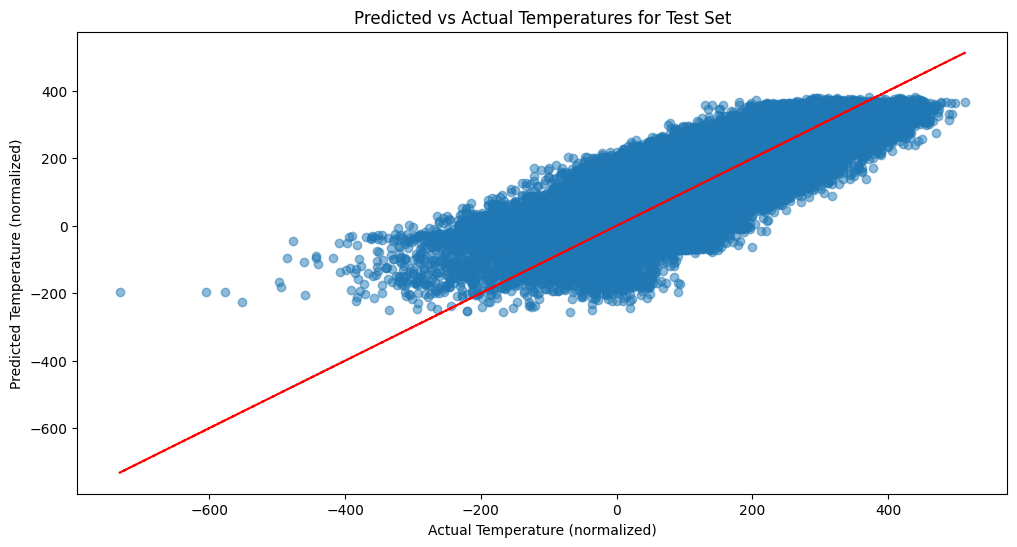

In [81]:
# Plot predicted vs actual temperatures for the test set
plt.figure(figsize=(12, 6))
plt.scatter(actuals, preds, alpha=0.5)
plt.plot(actuals, actuals, color='red', linestyle='--')  # Line y=x for reference
plt.xlabel('Actual Temperature (normalized)')
plt.ylabel('Predicted Temperature (normalized)')
plt.title('Predicted vs Actual Temperatures for Test Set')

Text(0.5, 1.0, 'Temperature Over Time for Station ID USC00192501, lon/lat: 41.3853, 41.3853, Name: EDGARTOWN')

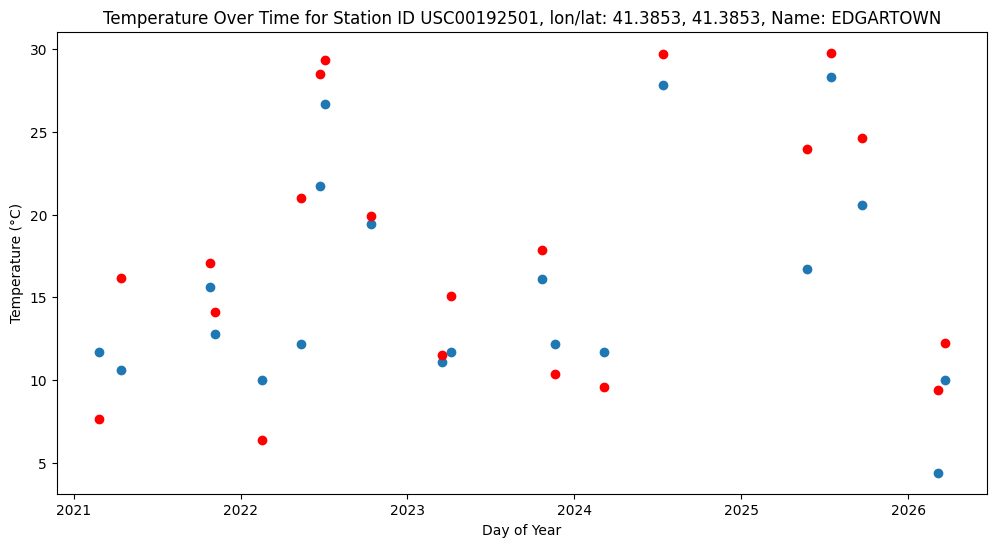

In [71]:
# Select random station from the test set
random_station = random.choice(ids[(splits != train_split).numpy()].to_numpy())
station_name = ghcn_qc_temp_df[ghcn_qc_temp_df['ID'] == random_station]['Name'].values[0]

# random_station = random.choice(ids.unique())
station_data = temp_data[(ids == random_station).to_numpy(), :]
station_dates = dates[(ids == random_station).to_numpy()]
station_splits = splits[(ids == random_station).to_numpy()]
station_coords = station_data[:, :3].detach().clone().to(device).double()
station_embeddings = spatiotemporal_enc(station_coords).detach()
station_preds = pred_model(station_embeddings.double().to(device)).cpu().detach().numpy()

plt.figure(figsize=(12, 6))
plt.scatter(station_dates, station_data[:, 3]/10, marker='o', linestyle='-', label=f'All data from station')
plt.scatter(station_dates, station_preds/10, marker='o', color="red", linestyle='-', label=f'Predicted data from station')
plt.xlabel('Day of Year')
plt.ylabel('Temperature (°C)')
plt.title(f'Temperature Over Time for Station ID {random_station}, lon/lat: {station_coords[0, 0].item():.4f}, {station_coords[0, 1].item():.4f}, Name: {station_name}')

In [50]:
# Load the GTLoc model
import gtloc
gtloc_ckpt = "/home/leca5365/Documents/gtloc/ckpts/gtloc.pt"
gtl_model = gtloc.GTLoc(
        hidden_dim= 768,
        embedding_dim= 512,
        queue_size=4096,
        time_sigma=[2**0, 2**4, 2**8],
        loc_sigma= [2**0, 2**4, 2**8],
        freeze_backbone=True,
        galleries='data_dist',
        time_dropout=0.1,
)
state_dict = torch.load(gtloc_ckpt, map_location='cpu', weights_only=True)
gtl_model.load_state_dict(state_dict, strict=False)

gtl_model = gtl_model.to(device)
gtl_loc_encoder = gtl_model.location_encoder
gtl_time_encoder = gtl_model.time_encoder

# Put times in the correct format
num_dates = len(dates)
month_days = torch.zeros(num_dates, 5)
month_days[:, 0] = torch.from_numpy(dates.dt.month.values).float()
month_days[:, 1] = torch.from_numpy(dates.dt.day.values).float()

# Put locations into the correct format, from lon_lat to lat_lon
lat_lon = temp_data[:, :2]
lat_lon[:, 0], lat_lon[:, 1] = lat_lon[:, 1], lat_lon[:, 0]

with torch.no_grad():
    loc_emb = gtl_loc_encoder(lat_lon.to(device))
    time_emb = gtl_time_encoder(month_days.to(device))
    gtl_emb = torch.cat([loc_emb, time_emb], dim=1)

train_gtl_emb = gtl_emb[splits == train_split, :]
test_gtl_emb = gtl_emb[splits != train_split, :]

print("Location embeddings shape:", loc_emb.shape)
print("Time embeddings shape:", time_emb.shape)
print("Combined embeddings shape:", gtl_emb.shape)
print("Train embeddings shape:", train_gtl_emb.shape)
print("Test embeddings shape:", test_gtl_emb.shape)

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

Location embeddings shape: torch.Size([200000, 512])
Time embeddings shape: torch.Size([200000, 512])
Combined embeddings shape: torch.Size([200000, 1024])
Train embeddings shape: torch.Size([102775, 1024])
Test embeddings shape: torch.Size([97225, 1024])


In [74]:
# Create a DataLoader for the train embeddings and values
train_dataset = torch.utils.data.TensorDataset(train_gtl_emb, train_sample[:, 3].detach().clone().double().to(device).unsqueeze(1))
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=8096, shuffle=True)

# Test dataloader
test_dataset = torch.utils.data.TensorDataset(test_gtl_emb, test_sample[:, 3].detach().clone().double().to(device).unsqueeze(1))
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=8096, shuffle=False)

if EVAL_TYPE == "mlp": 
  pred_model = MLP(input_dim=train_gtl_emb.shape[1], dim_hidden=64, num_layers=2, out_dims=1).double().to(device)
elif EVAL_TYPE == "linear":
  pred_model = nn.Linear(train_gtl_emb.shape[1], 1, dtype=torch.float64).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(pred_model.parameters(), lr=1e-3)

epoch_losses = []
epochs = 200
running_loss = torch.zeros(1, device=device)

for epoch in range(epochs):
  pred_model.train()
  running_loss.zero_()  # Reset running loss for the epoch

  for batch in train_loader:
    optimizer.zero_grad()
    embeddings, values = batch
    # Forward pass
    y_pred = pred_model(embeddings.to(device).double())
    # Compute the loss
    loss = criterion(y_pred, values.to(device).double())
    # Backward pass
    loss.backward()
    # Update the parameters
    optimizer.step()
    # Append the loss to the list
    # losses.append(loss.item())

    running_loss += loss.detach() * embeddings.size(0)  # Multiply by batch size to get total loss for the batch

  epoch_loss = (running_loss / len(train_loader.dataset)).item()
  epoch_losses.append(epoch_loss)

  if (epoch) % 10 == 0:
    print(f"Epoch {epoch + 1}, Loss: {epoch_loss:.4f}")

Epoch 1, Loss: 45842.5156
Epoch 11, Loss: 15744.8779
Epoch 21, Loss: 11599.5098
Epoch 31, Loss: 6352.8374
Epoch 41, Loss: 5729.4077
Epoch 51, Loss: 5075.4849
Epoch 61, Loss: 4754.4019
Epoch 71, Loss: 4569.0332
Epoch 81, Loss: 4460.5059
Epoch 91, Loss: 4375.0469
Epoch 101, Loss: 4337.9429
Epoch 111, Loss: 4259.5073
Epoch 121, Loss: 4215.3525
Epoch 131, Loss: 4172.6304
Epoch 141, Loss: 4145.1558
Epoch 151, Loss: 4115.2280
Epoch 161, Loss: 4102.6084
Epoch 171, Loss: 4072.0291
Epoch 181, Loss: 4051.0505
Epoch 191, Loss: 4033.9192


In [75]:
# Run test
preds = []
actuals = []

with torch.no_grad():
  pred_model.eval()

  for batch in test_loader:
    embeddings, values = batch
    y_pred_test = pred_model(embeddings.double().to(device))
    preds.extend(y_pred_test.cpu().detach().numpy())
    actuals.extend(values.double().to(device).cpu().detach().numpy())

# Print test loss
print(f'Test loss: {criterion(torch.tensor(preds), torch.tensor(actuals)).item()}')

# Print test RMSE
test_rmse = torch.sqrt(F.mse_loss(torch.tensor(preds), torch.tensor(actuals))).item()
print(f'Test RMSE: {test_rmse/10} °C')

Test loss: 4769.42792155126
Test RMSE: 6.906104489182928 °C


Text(0.5, 1.0, 'Predicted vs Actual Temperatures for Test Set')

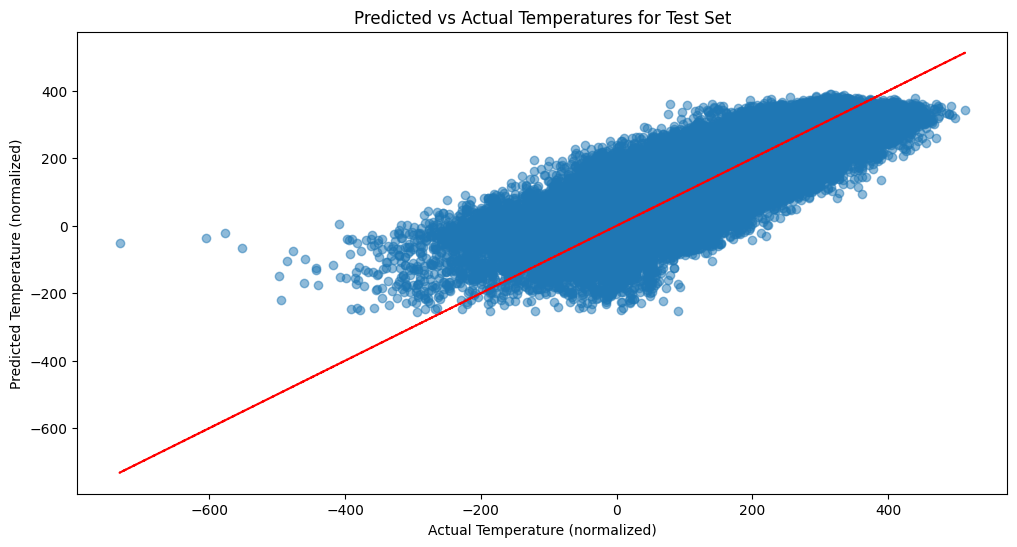

In [76]:
# Plot predicted vs actual temperatures for the test set
plt.figure(figsize=(12, 6))
plt.scatter(actuals, preds, alpha=0.5)
plt.plot(actuals, actuals, color='red', linestyle='--')  # Line y=x for reference
plt.xlabel('Actual Temperature (normalized)')
plt.ylabel('Predicted Temperature (normalized)')
plt.title('Predicted vs Actual Temperatures for Test Set')

In [126]:
# Create a DataLoader for the train embeddings and values
train_dataset = torch.utils.data.TensorDataset(train_sample[:, :3].detach().clone().double().to(device), train_sample[:, 3].detach().clone().double().to(device).unsqueeze(1))
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=8096, shuffle=True)

# Test dataloader
test_dataset = torch.utils.data.TensorDataset(test_sample[:, :3].detach().clone().double().to(device), test_sample[:, 3].detach().clone().double().to(device).unsqueeze(1))
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=8096, shuffle=False)

if EVAL_TYPE == "mlp": 
  simple_model = MLP(input_dim=3, dim_hidden=64, num_layers=2, out_dims=1).double().to(device)
elif EVAL_TYPE == "linear":
  simple_model = nn.Linear(train_sample[:, :3].shape[1], 1, dtype=torch.float64).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(simple_model.parameters(), lr=1e-3)

epoch_losses = []
epochs = 200
running_loss = torch.zeros(1, device=device)

for epoch in range(epochs):
  simple_model.train()
  running_loss.zero_()  # Reset running loss for the epoch

  for batch in train_loader:
    optimizer.zero_grad()
    coords, values = batch
    # Forward pass
    y_pred = simple_model(coords.to(device))
    # Compute the loss
    loss = criterion(y_pred, values.to(device))
    # Backward pass
    loss.backward()
    # Update the parameters
    optimizer.step()
    # Append the loss to the list
    # losses.append(loss.item())

    running_loss += loss.detach() * coords.size(0)  # Multiply by batch size to get total loss for the batch

  epoch_loss = (running_loss / len(train_loader.dataset)).item()
  epoch_losses.append(epoch_loss)

  if (epoch) % 10 == 0:
    print(f"Epoch {epoch + 1}, Loss: {epoch_loss:.4f}")

Epoch 1, Loss: 36916.0820
Epoch 11, Loss: 35539.3047
Epoch 21, Loss: 34711.8984
Epoch 31, Loss: 34119.4141
Epoch 41, Loss: 33597.3164
Epoch 51, Loss: 33103.1758
Epoch 61, Loss: 32634.8945
Epoch 71, Loss: 32193.9023
Epoch 81, Loss: 31782.0020
Epoch 91, Loss: 31399.1562
Epoch 101, Loss: 31044.8574
Epoch 111, Loss: 30718.5840
Epoch 121, Loss: 30419.1719
Epoch 131, Loss: 30145.2344
Epoch 141, Loss: 29895.9863
Epoch 151, Loss: 29670.0234
Epoch 161, Loss: 29465.6172
Epoch 171, Loss: 29281.7734
Epoch 181, Loss: 29117.0156
Epoch 191, Loss: 28969.9531


In [127]:
# Run test
preds = []
actuals = []

with torch.no_grad():
  simple_model.eval()

  for batch in test_loader:
    coords, values = batch
    y_pred_test = simple_model(coords.to(device))
    preds.extend(y_pred_test.cpu().detach().numpy())
    actuals.extend(values.to(device).cpu().detach().numpy())

# Print test loss
print(f'Test loss: {criterion(torch.tensor(preds), torch.tensor(actuals)).item()}')

# Print test RMSE
test_rmse = torch.sqrt(F.mse_loss(torch.tensor(preds), torch.tensor(actuals))).item()
print(f'Test RMSE: {test_rmse/10} °C')

Test loss: 28848.386833167548
Test RMSE: 16.984812873024993 °C


Text(0.5, 1.0, 'Predicted vs Actual Temperatures for Test Set')

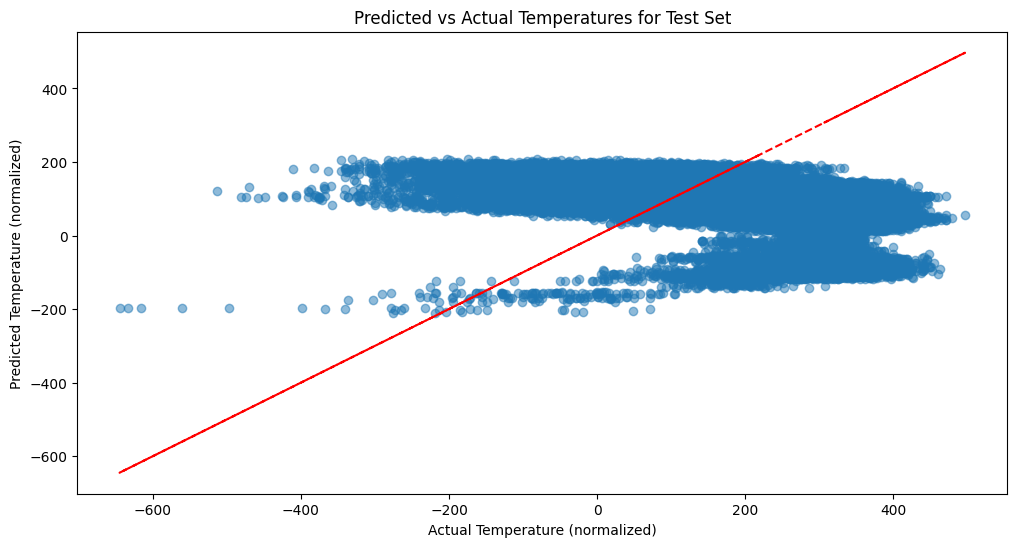

In [128]:
# Plot predicted vs actual temperatures for the test set
plt.figure(figsize=(12, 6))
plt.scatter(actuals, preds, alpha=0.5)
plt.plot(actuals, actuals, color='red', linestyle='--')  # Line y=x for reference
plt.xlabel('Actual Temperature (normalized)')
plt.ylabel('Predicted Temperature (normalized)')
plt.title('Predicted vs Actual Temperatures for Test Set')

Text(0.5, 1.0, 'Temperature Over Time for Station ID SP000008215, lon/lat: -4.0103, 40.7806, Name: NAVACERRADA')

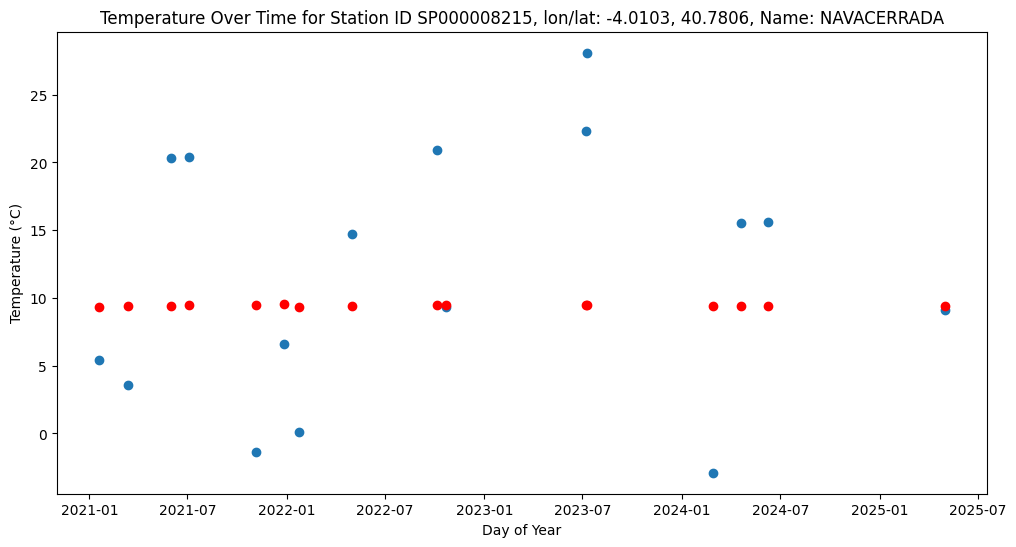

In [135]:
# Select random station from the test set
random_station = random.choice(ids[(splits != train_split).numpy()].to_numpy())
station_name = ghcn_qc_temp_df[ghcn_qc_temp_df['ID'] == random_station]['Name'].values[0]

# random_station = random.choice(ids.unique())
station_data = temp_data[(ids == random_station).to_numpy(), :]
station_dates = dates[(ids == random_station).to_numpy()]
station_splits = splits[(ids == random_station).to_numpy()]
station_coords = station_data[:, :3].detach().clone().to(device).double()
station_preds = simple_model(station_coords.double().to(device)).cpu().detach().numpy()

plt.figure(figsize=(12, 6))
plt.scatter(station_dates, station_data[:, 3]/10, marker='o', linestyle='-', label=f'All data from station')
plt.scatter(station_dates, station_preds/10, marker='o', color="red", linestyle='-', label=f'Predicted data from station')
plt.xlabel('Day of Year')
plt.ylabel('Temperature (°C)')
plt.title(f'Temperature Over Time for Station ID {random_station}, lon/lat: {station_coords[0, 0].item():.4f}, {station_coords[0, 1].item():.4f}, Name: {station_name}')

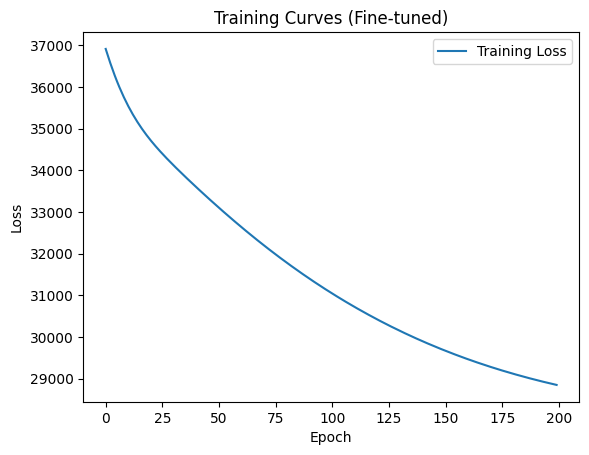

In [136]:
# Plot training curves for the fine-tuned model
plt.plot(list(range(len(epoch_losses))), epoch_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Curves (Fine-tuned)')
plt.legend()
plt.show()